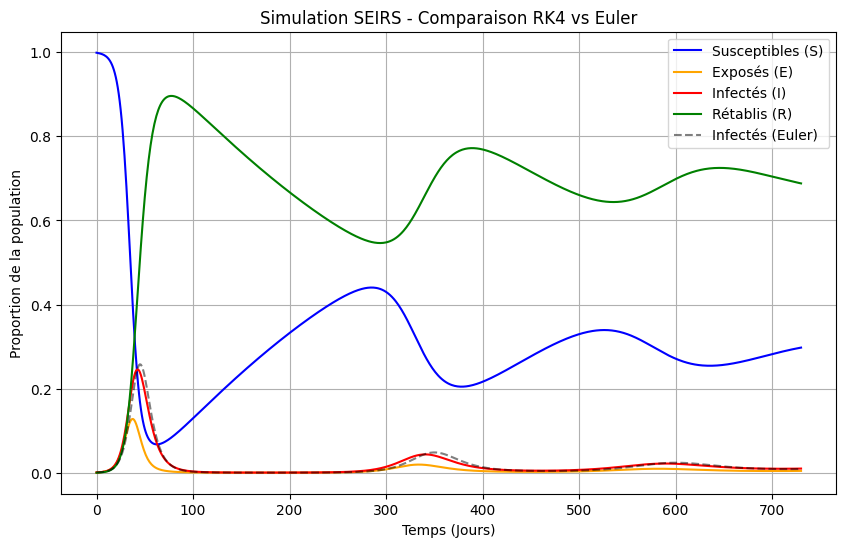

Simulation terminée !
Max d'infectés (RK4) : 0.2457
Max d'infectés (Euler) : 0.2579


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres du projet ---

RHO = 1/365   # Perte d'immunité
BETA = 0.5    # Taux d'infection
SIGMA = 1/3   # Fin d'incubation
GAMMA = 1/7   # Guérison

# Durée de la simulation (en jours)
JOURS = 730
dt = 1.0  # Pas de temps de 1 jour

# Création du tableau de temps de 0 à 730
temps = np.arange(0, JOURS + dt, dt)

# --- Définition des équations différentielles (ODE) ---
def calcul_derivees(t, y):
    """
    Fonction qui calcule les dérivées dS, dE, dI, dR
    y contient [S, E, I, R]
    """
    S, E, I, R = y

    # Équations du modèle SEIRS
    dS = -BETA * S * I + RHO * R
    dE = BETA * S * I - SIGMA * E
    dI = SIGMA * E - GAMMA * I
    dR = GAMMA * I - RHO * R

    return np.array([dS, dE, dI, dR])

# --- Méthode 1 : Euler Explicite ---
def methode_euler(y_init, t_array):
    nb_points = len(t_array)
    # On prépare un tableau pour stocker les résultats
    # 4 colonnes pour S, E, I, R
    resultats = np.zeros((nb_points, 4))

    # On met les conditions initiales à l'indice 0
    resultats[0] = y_init

    # Boucle pour calculer jour après jour
    for i in range(nb_points - 1):
        dt_actuel = t_array[i+1] - t_array[i]
        etat_courant = resultats[i]

        # Formule d'Euler : y(t+dt) = y(t) + f(y,t) * dt
        derivees = calcul_derivees(t_array[i], etat_courant)
        resultats[i+1] = etat_courant + derivees * dt_actuel

    return resultats

# --- Méthode 2 : Runge-Kutta ordre 4 (RK4) ---
def methode_rk4(y_init, t_array):
    nb_points = len(t_array)
    resultats = np.zeros((nb_points, 4))
    resultats[0] = y_init

    for i in range(nb_points - 1):
        dt_actuel = t_array[i+1] - t_array[i]
        etat = resultats[i]
        t = t_array[i]

        # Calcul des coefficients k1, k2, k3, k4
        k1 = calcul_derivees(t, etat)
        k2 = calcul_derivees(t + dt_actuel/2, etat + k1 * dt_actuel/2)
        k3 = calcul_derivees(t + dt_actuel/2, etat + k2 * dt_actuel/2)
        k4 = calcul_derivees(t + dt_actuel, etat + k3 * dt_actuel)

        # Moyenne pondérée pour trouver le point suivant
        pente_moyenne = (k1 + 2*k2 + 2*k3 + k4) / 6
        resultats[i+1] = etat + pente_moyenne * dt_actuel

    return resultats

# --- Simulation ---

# Conditions initiales : S=0.999, E=0, I=0.001, R=0
etat_initial = [0.999, 0.0, 0.001, 0.0]

# On lance les deux méthodes
res_euler = methode_euler(etat_initial, temps)
res_rk4 = methode_rk4(etat_initial, temps)

# --- Affichage des graphiques ---
plt.figure(figsize=(10, 6))

# On trace les courbes pour RK4 (plus précis)
plt.plot(temps, res_rk4[:, 0], label='Susceptibles (S)', color='blue')
plt.plot(temps, res_rk4[:, 1], label='Exposés (E)', color='orange')
plt.plot(temps, res_rk4[:, 2], label='Infectés (I)', color='red')
plt.plot(temps, res_rk4[:, 3], label='Rétablis (R)', color='green')

# On ajoute Euler en pointillé juste pour l'Infection (pour comparer sans surcharger)
plt.plot(temps, res_euler[:, 2], 'k--', alpha=0.5, label='Infectés (Euler)')

plt.title('Simulation SEIRS - Comparaison RK4 vs Euler')
plt.xlabel('Temps (Jours)')
plt.ylabel('Proportion de la population')
plt.legend()
plt.grid(True)
plt.show()

# Petite vérification console
print("Simulation terminée !")
print(f"Max d'infectés (RK4) : {max(res_rk4[:,2]):.4f}")
print(f"Max d'infectés (Euler) : {max(res_euler[:,2]):.4f}")


In [ ]:
%%writefile simulation_seirs.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <fstream>
#include <iomanip>

using namespace std;

// --- Paramètres du modèle ---
const double RHO = 1.0/365.0;   // Perte immunité
const double BETA = 0.5;        // Infection
const double SIGMA = 1.0/3.0;   // Incubation
const double GAMMA = 1.0/7.0;   // Guérison

// Structure pour stocker l'état (S, E, I, R)
struct Etat {
    double S;
    double E;
    double I;
    double R;
};

// --- Calcul des dérivées (le cœur du modèle) ---
Etat calcul_derivees(double t, Etat y) {
    Etat d;
    d.S = -BETA * y.S * y.I + RHO * y.R;
    d.E = BETA * y.S * y.I - SIGMA * y.E;
    d.I = SIGMA * y.E - GAMMA * y.I;
    d.R = GAMMA * y.I - RHO * y.R;
    return d;
}

// Opérateurs utiles pour simplifier les calculs (addition et multiplication de vecteurs)
Etat operator+(const Etat& a, const Etat& b) {
    return {a.S + b.S, a.E + b.E, a.I + b.I, a.R + b.R};
}

Etat operator*(const Etat& a, double k) {
    return {a.S * k, a.E * k, a.I * k, a.R * k};
}

// --- Méthode d'Euler ---
void simulation_euler(Etat y0, double dt, int nb_jours, string nom_fichier) {
    ofstream fichier(nom_fichier);
    fichier << "t,S,E,I,R\n"; // En-tête CSV

    Etat y = y0;
    double t = 0;

    for (int i = 0; i <= nb_jours; ++i) {
        // Sauvegarde dans le fichier
        fichier << t << "," << y.S << "," << y.E << "," << y.I << "," << y.R << "\n";

        // Calcul Euler
        Etat derivees = calcul_derivees(t, y);
        y = y + derivees * dt; // y(t+dt) = y(t) + f(y,t)*dt
        t += dt;
    }
    fichier.close();
    cout << "Simulation Euler terminee -> " << nom_fichier << endl;
}

// --- Méthode RK4 ---
void simulation_rk4(Etat y0, double dt, int nb_jours, string nom_fichier) {
    ofstream fichier(nom_fichier);
    fichier << "t,S,E,I,R\n";

    Etat y = y0;
    double t = 0;

    for (int i = 0; i <= nb_jours; ++i) {
        fichier << t << "," << y.S << "," << y.E << "," << y.I << "," << y.R << "\n";

        Etat k1 = calcul_derivees(t, y);
        Etat k2 = calcul_derivees(t + dt/2, y + k1 * (dt/2));
        Etat k3 = calcul_derivees(t + dt/2, y + k2 * (dt/2));
        Etat k4 = calcul_derivees(t + dt, y + k3 * dt);

        // Formule RK4
        Etat pente_moyenne = (k1 + k2 * 2.0 + k3 * 2.0 + k4) * (1.0/6.0);
        y = y + pente_moyenne * dt;
        t += dt;
    }
    fichier.close();
    cout << "Simulation RK4 terminee -> " << nom_fichier << endl;
}

int main() {
    // Conditions initiales
    Etat y_init = {0.999, 0.0, 0.001, 0.0};
    int jours = 730;
    double dt = 1.0;

    // Lancement des simulations
    simulation_euler(y_init, dt, jours, "resultats_cpp_euler.csv");
    simulation_rk4(y_init, dt, jours, "resultats_cpp_rk4.csv");

    return 0;
}


Writing simulation_seirs.cpp


In [ ]:
!g++ simulation_seirs.cpp -o simu_seirs
!./simu_seirs


Simulation Euler terminee -> resultats_cpp_euler.csv
Simulation RK4 terminee -> resultats_cpp_rk4.csv


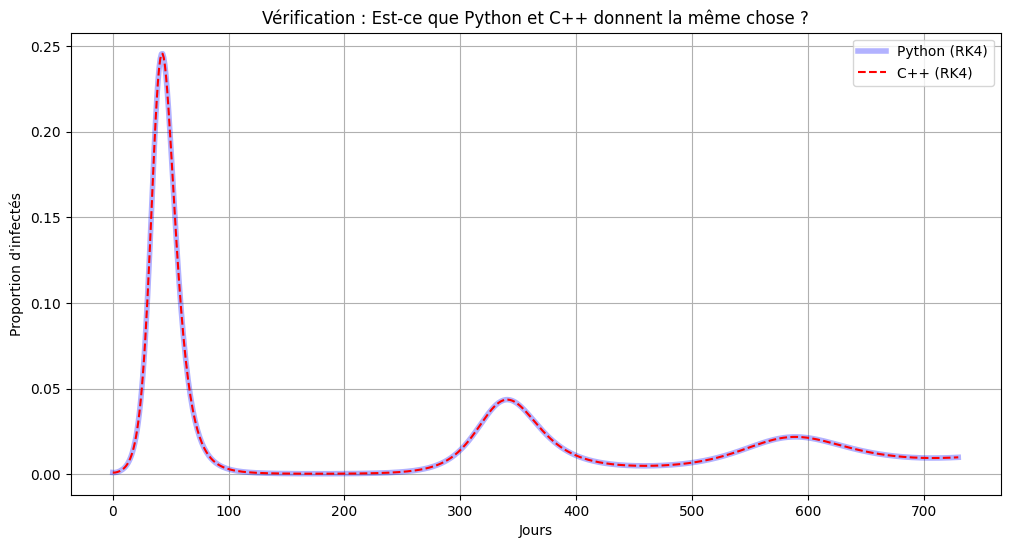

L'écart maximum trouvé est de : 4.926311428232744e-07
Attention : Il y a une petite différence.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Chargement des fichiers générés par le C++ ---
# On lit les fichiers CSV créés juste avant
donnees_cpp_euler = pd.read_csv('resultats_cpp_euler.csv')
donnees_cpp_rk4 = pd.read_csv('resultats_cpp_rk4.csv')

# --- Comparaison Python vs C++ ---
# On va regarder si les courbes se superposent bien

plt.figure(figsize=(12, 6))

# On trace d'abord la courbe Python en trait épais bleu transparent

plt.plot(temps, res_rk4[:, 2],
         color='blue', linewidth=4, alpha=0.3,
         label='Python (RK4)')

# On trace ensuite la courbe C++ en rouge pointillé par-dessus
plt.plot(donnees_cpp_rk4['t'], donnees_cpp_rk4['I'],
         'r--',
         label='C++ (RK4)')

plt.title("Vérification : Est-ce que Python et C++ donnent la même chose ?")
plt.xlabel("Jours")
plt.ylabel("Proportion d'infectés")
plt.legend()
plt.grid(True)
plt.show()

# --- Calcul précis de l'erreur ---
# On calcule la différence point par point entre les deux tableaux
difference = abs(res_rk4[:, 2] - donnees_cpp_rk4['I'])
max_erreur = max(difference)

print(f"L'écart maximum trouvé est de : {max_erreur}")

if max_erreur < 1e-9: # 1e-9 veut dire 0.000000001
    print("Conclusion : C'est parfait ! Les résultats sont identiques.")
else:
    print("Attention : Il y a une petite différence.")
